<a href="https://colab.research.google.com/github/etbarash2/musicComputing2026classWork/blob/main/labassignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display

In [22]:
def plotAudio2(sig,sampleRate,title):
  time = np.arange(0,sig.shape[0])/sampleRate

  excursion=max(abs(sig))
  sigNew = sig/excursion

  xlabel = "Time (seconds)"
  ylabel = "Amplitude"

  plt.plot(time,sigNew)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.show()
    # from Assignment 2/Google Doc


In [23]:
def plotAudioFreqDomain(sig,sr,title,winSize,specType):
  spec = librosa.amplitude_to_db(np.abs(librosa.stft(sig,n_fft=winSize)), ref=np.max)
  librosa.display.specshow(spec, y_axis=specType)
  plt.colorbar(format='%+2.0f dB')
  plt.title('Log-frequency power spectrogram')
  plt.show()
    # from Assignment 3

In [24]:
def additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent):
    harmonics = np.arange(1,numHarmonics+1,seqHarm)
    harmonics = harmonics[1:-1]

    # create a time series from 0 to 1 the inputted length
    timeSeries = np.linspace(0, 1, samplingRate)

    # create a cosine wave for the fundamental
    signal = np.cos(2.0 * np.pi * frequency * timeSeries)

    # add harmonics based on the those specified in the variable 'harmonics'
    for harm in harmonics:
        signal = signal + np.cos(2.0 * np.pi * frequency * harm * timeSeries)/harm**ampExponent

    # scale the signal to between -1 and 1
    excursion=max(abs(signal))
    signal = signal / excursion

    # plot signal
    plt.plot(timeSeries,signal)
    plt.xlabel('Time (Sec)')
    plt.ylabel('Amplitude')
    plt.title('Additive Synthesis')
    plt.plot

    return signal
   # from additiveSynthesis.ipynb

In [25]:
def makeWaveforms(frequency,samplingRate,numHarmonics,waveType):
    # use an if/elif/else statement to set up the parameters for
    # the different type of waveforms based on the code in
    # additiveSynthesis.ipynb
    # if, elif (else if) and else can be used to evaluate the contents of a variable
    if waveType == 'sawtooth':
      seqHarm = 1
      ampExponent = 1
    elif waveType == 'square':
      seqHarm = 2
      ampExponent = 1
    elif waveType == 'triangle':
      seqHarm = 2
      ampExponent = 2
    else:
      numHarmonics = 1
      seqHarm = 1
      ampExponent = 1

    # call additiveSynthesis() to generate a waveform
    signal = additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent)
    # return the generated waveform (signal)
    return signal


In [26]:
def visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType):
  # call makeWaveform()
  sig = makeWaveforms(frequency,samplingRate,numHarmonics,waveType)
  # test whether makeWaveforms() runs without error before you try plotting anything
  sampleRate = samplingRate
  sr = samplingRate
  title = waveType
  # call plotAudio2()
  plotAudio2(sig,sampleRate,title)
  # call plotAudioFreqDomain()
  plotAudioFreqDomain(sig,sr,title,winSize,specType)
  # return the output of makeWaveform()
  return sig

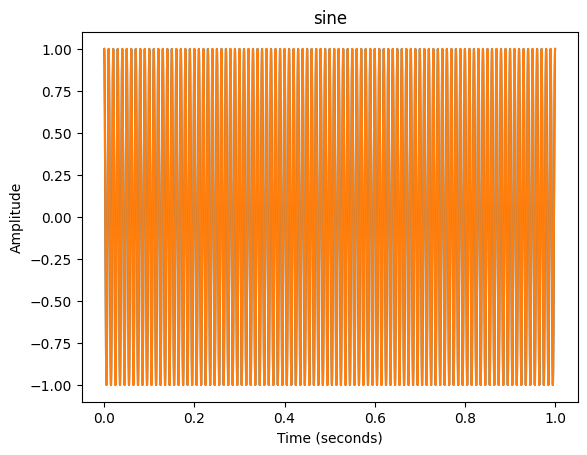

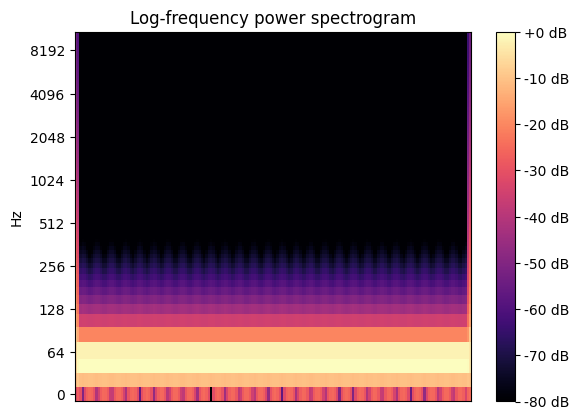

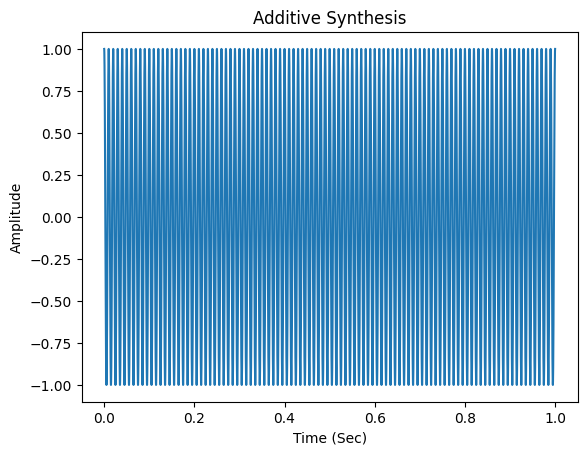

In [27]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sine'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType)
IPython.display.Audio(makeWaveforms(frequency,samplingRate,numHarmonics,waveType), rate=samplingRate)

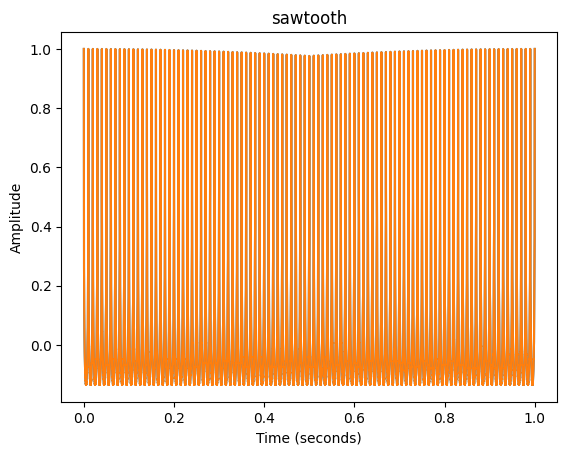

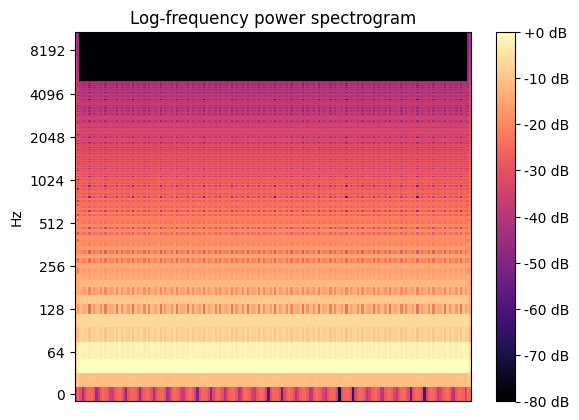

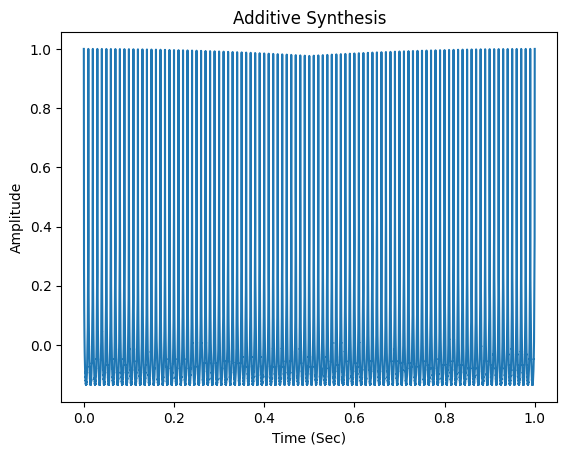

In [28]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sawtooth'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType)
IPython.display.Audio(makeWaveforms(frequency,samplingRate,numHarmonics,waveType), rate=samplingRate)

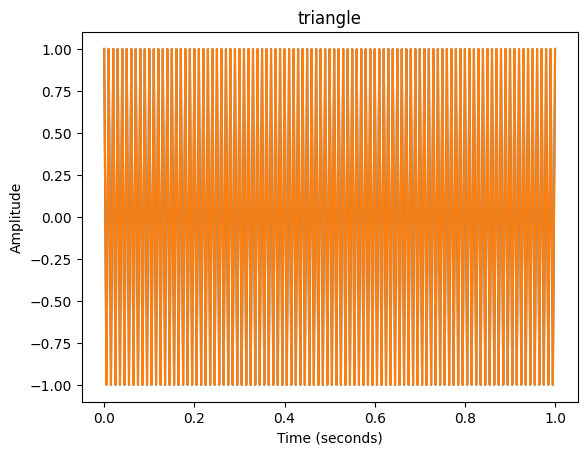

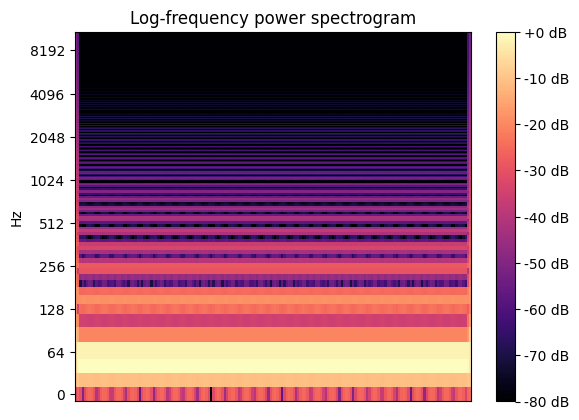

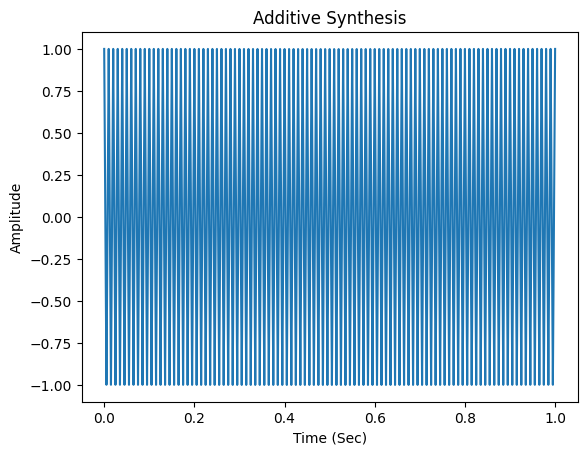

In [29]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'triangle'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType)
IPython.display.Audio(makeWaveforms(frequency,samplingRate,numHarmonics,waveType), rate=samplingRate)

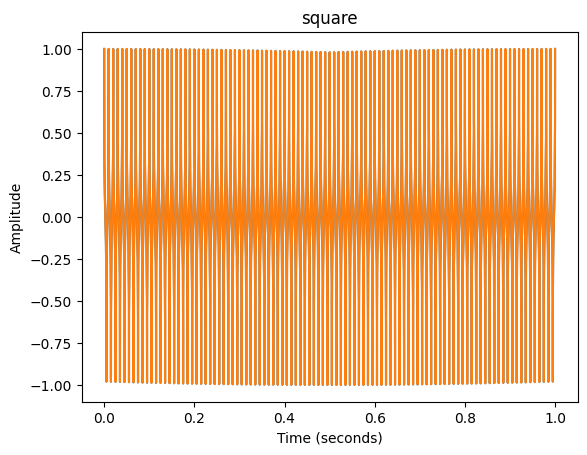

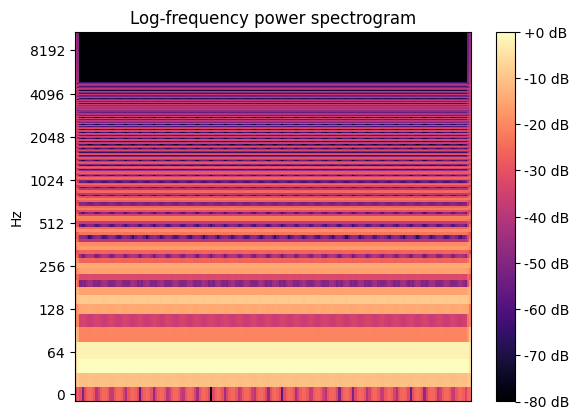

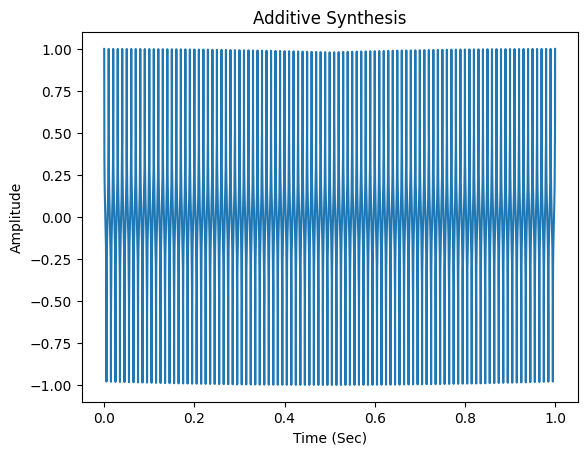

In [30]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'square'
winSize = 1024
specType = 'log'

visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType)
IPython.display.Audio(makeWaveforms(frequency,samplingRate,numHarmonics,waveType), rate=samplingRate)